# Object Detection — Stage 1 (Localisation)

Trains `ObjectDetectorResNet` to predict up to `MAX_OBJECTS` bounding boxes per image.  
Each predicted slot is `[x, y, w, h, conf]`; confidence is a raw logit trained with BCE.

**Pipeline:**  
`get_detection_loaders` → `ObjectDetectorResNet` → `DetectionLoss` → `fit(task_type='detection')`

In [1]:
import sys
sys.path.insert(0, '..')

import torch

from utils.dataset   import get_detection_loaders
from utils.trainer   import fit, evaluate_detection_sweep, evaluate_detection
from utils.callbacks import ModelCheckpoint
from utils.losses    import DetectionLoss
from models import get_detector

# ── Config ────────────────────────────────────────────────────────────────────
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ROOT_DIR    = '../data'
BATCH_SIZE  = 198
EPOCHS      = 60
MAX_OBJECTS = 24      # must match generator max_objects
CONF_THRESH = 0.5     # sigmoid threshold at inference
LAMBDA_CONF = 1.0     # weight on confidence loss

print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device : cuda
PyTorch: 2.11.0+cu130


## 1 · Data Loaders

In [2]:
train_loader, val_loader, test_loader = get_detection_loaders(
    batch_size = BATCH_SIZE,
    test=True,
)

# ── Sanity check ──────────────────────────────────────────────────────────────
batch = next(iter(train_loader))
imgs, boxes, labels, mask = batch

print(f'Image batch shape : {imgs.shape}')
print(f'GT boxes shape    : {boxes.shape}')
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Image batch shape : torch.Size([198, 1, 224, 224])
GT boxes shape    : torch.Size([198, 17, 4])
Train batches: 1213 | Val batches: 76


## 2 · Model

In [3]:
model = get_detector(size="s", max_objects=MAX_OBJECTS).to(DEVICE)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

# ── Forward smoke-test ────────────────────────────────────────────────────────
with torch.no_grad():
    out = model(imgs.to(DEVICE))
print(f'Output shape: {out.shape}')  # (B, MAX_OBJECTS, 5)  — [x, y, w, h, conf]

Parameters: 2,227,128
Output shape: torch.Size([198, 24, 5])


## 3 · Loss — Huber + BCE confidence

`DetectionLoss` lives in `utils/losses.py`:
- Greedy IoU match → each GT box assigned to the best predicted slot
- **Box loss**: `HuberLoss` on matched pairs
- **Conf loss**: `BCEWithLogitsLoss` — matched slots → 1.0, background → 0.0

In [4]:
criterion = DetectionLoss(lambda_conf=LAMBDA_CONF, delta=1.0)
print('DetectionLoss ready.')

# ── Quick loss smoke-test ─────────────────────────────────────────────────────
boxes_v = boxes.to(DEVICE)
mask_v = mask.to(DEVICE)

with torch.no_grad():
    dummy_out   = model(imgs.to(DEVICE))
    loss_val    = criterion(dummy_out, boxes_v, mask_v)
print(f'Smoke-test loss: {loss_val.item():.4f}')  # should be finite

DetectionLoss ready.
Smoke-test loss: 59.8594


## 4 · Optimiser & Scheduler

In [5]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = 1e-3,
    weight_decay = 1e-4,
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr          = 1e-3,
    steps_per_epoch = len(train_loader),
    epochs          = EPOCHS,
)

NAME = "detector_S_V2"
checkpoint = ModelCheckpoint(
    model, verbose=False,
    checkpoint_path=f"../checkpoint/{NAME}_latest.pth",
    best_model_path=f"../checkpoint/{NAME}_best.pth",
    mode='max'   # maximise val_iou
)

scaler = torch.amp.GradScaler('cuda')

print(f'Optimizer : {type(optimizer).__name__}')
print(f'Scheduler : {type(scheduler).__name__}')

Optimizer : AdamW
Scheduler : OneCycleLR


## 5 · Train

In [6]:
history, logger = fit(
    model       = model,
    trainloader = train_loader,
    valloader   = val_loader,
    criterion   = criterion,
    optimizer   = optimizer,
    device      = DEVICE,
    epochs      = EPOCHS,
    task_type   = 'detection',
    scheduler   = scheduler,
    scaler      = scaler,
    checkpoint  = checkpoint,
    step_scheduler_per_batch = True,
    verbose     = True,
    log         = True,
    model_label = NAME,
    resume=True
)

Training with bf16 autocast | Task: detection | Epochs: 60
[RunLogger] ▶  Run 'detector_s_v2_20260719_100048' started — saving to 'C:\OD-From-Scratch\logs\ObjectDetectorResNet\detector_s_v2_20260719_100048.json'
Could not resume training: No checkpoint found at '..\checkpoint\detector_S_V2_latest.pth'. Cannot resume training.
Batch  1 | match=1.00 hungar=2.9ms data=688.0ms pad=0.8ms forward=224.0ms loss=9.1ms backward=319.2ms step=173.9ms
Batch  2 | match=1.00 hungar=2.0ms data=0.2ms pad=0.8ms forward=15.3ms loss=7.2ms backward=33.2ms step=2.6ms
Batch  3 | match=1.00 hungar=2.4ms data=0.2ms pad=0.8ms forward=15.3ms loss=6.0ms backward=32.1ms step=1.9ms
Batch  4 | match=1.00 hungar=2.1ms data=0.2ms pad=0.8ms forward=15.2ms loss=6.0ms backward=32.1ms step=2.4ms
Batch  5 | match=1.00 hungar=2.3ms data=0.2ms pad=0.8ms forward=15.5ms loss=6.3ms backward=31.6ms step=2.5ms
  --> Epoch Average Match Ratio: 1.0000
Train: 72.5s | Val: 49.9s
[RunLogger] Epoch   1 | train_loss=22.2109  val_loss=15

## 6 · Training Curves

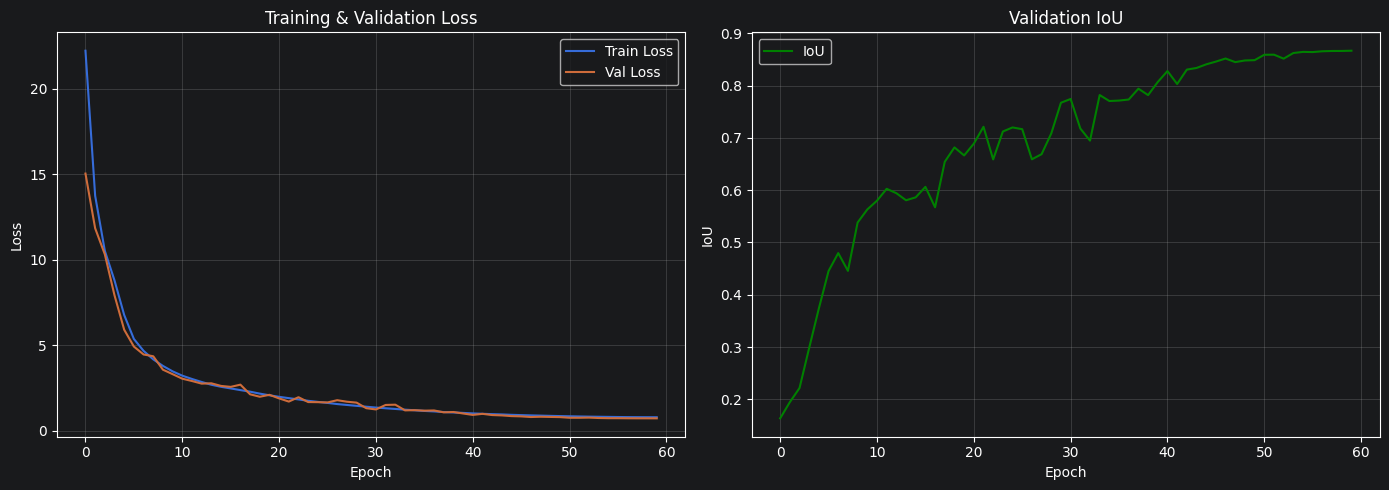

In [7]:
from utils.visualizer import Visualizer

Visualizer.visualize_training_curves(history['train_loss'], history['val_loss'], history['val_iou'], metric_label='IoU')

## 7 · Prediction Visualisation

- **Green** boxes = ground truth
- **Red** (dashed) boxes = model predictions with `conf > CONF_THRESH`

In [8]:
# -- Evaluate on Test Set (greedy IoU at conf=0.5) --
from utils.trainer import evaluate_detection
checkpoint.restore_best_weights()
metrics = evaluate_detection(model, test_loader, criterion, DEVICE)
print(f"Test loss : {metrics['val_loss']:.4f}")
print(f"Test IoU  : {metrics['val_iou']:.4f}")


Test loss : 0.7197
Test IoU  : 0.8660


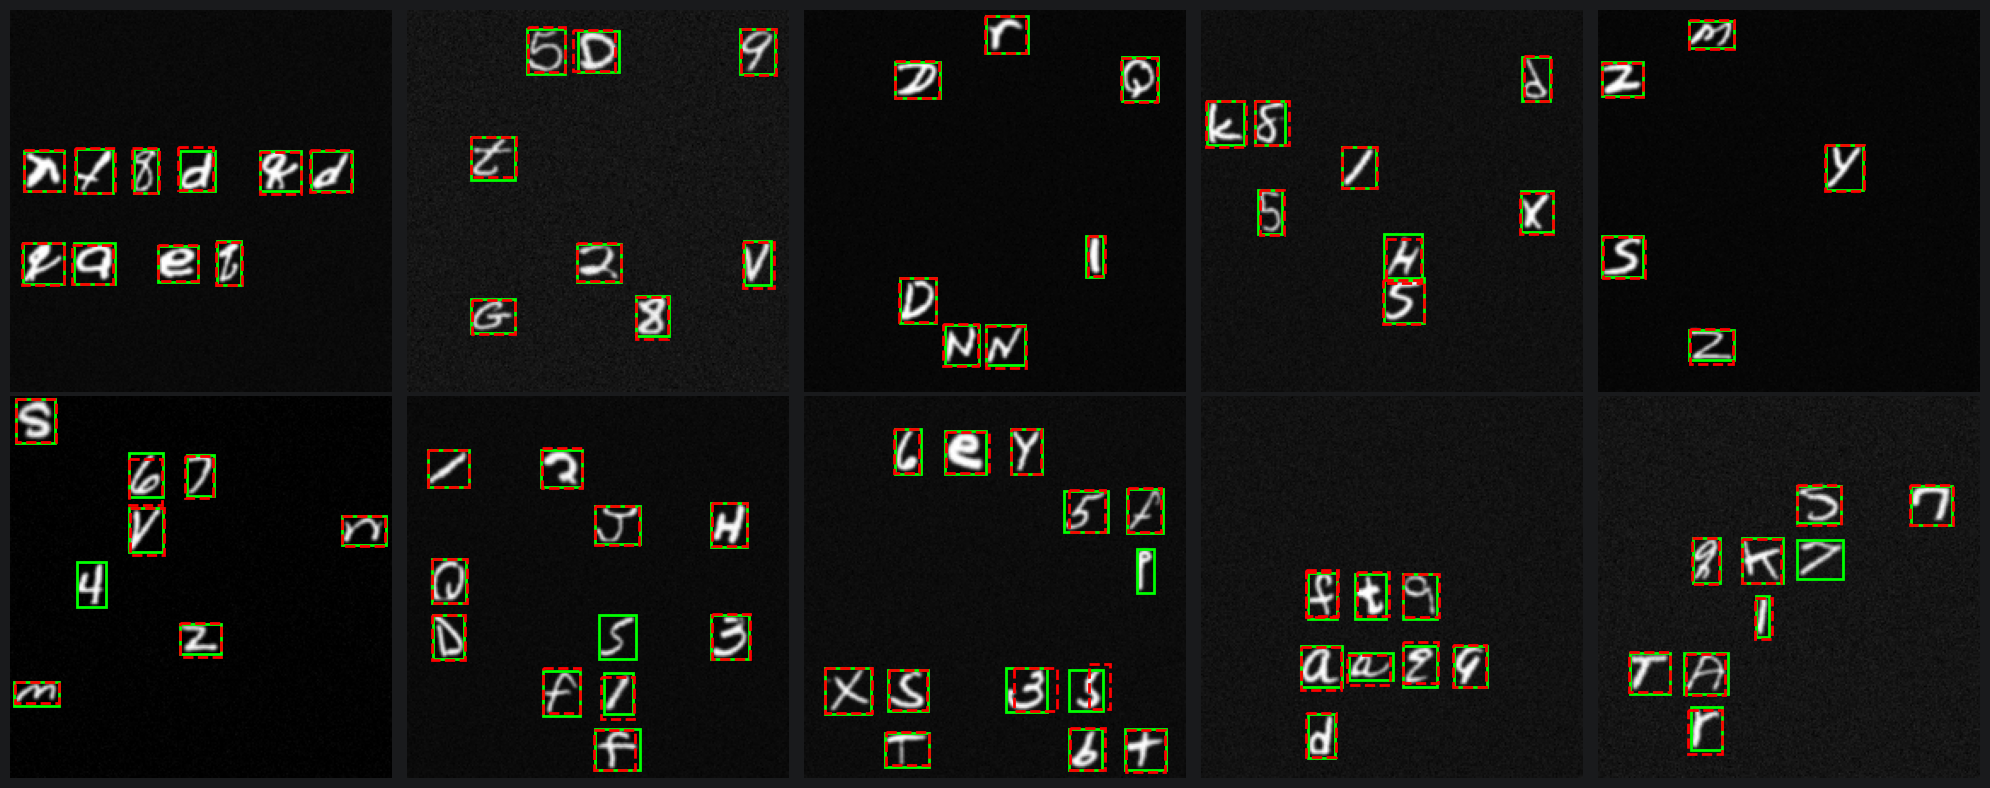

In [9]:
test_batch = next(iter(test_loader))
imgs_t, boxes_t, labels_t, mask_t = test_batch
with torch.no_grad():
    preds_t = model(imgs_t.to(DEVICE)).cpu()
Visualizer.visualize_multi_detection_batch(
    imgs_v=imgs_t,
    preds=preds_t,
    boxes_v=boxes_t,
    mask_v=mask_t,
    conf_thresh=CONF_THRESH
)

## 8 · Test-Set Confidence Threshold Sweep

Run `evaluate_detection_sweep` on the held-out **test set** to see the full P/R/F1 trade-off
across confidence thresholds. The model runs **once** and all thresholds are swept in pure NumPy,
so the sweep is fast.

Results can be saved into the run JSON under `test_results.threshold_sweep` via
`logger.log_test_results()`.

In [10]:
sweep_results = evaluate_detection_sweep(
    model, test_loader, DEVICE,
    iou_threshold=0.5,
    print_table=True,
)

if logger is not None:
    logger.log_test_results(sweep_results, iou_threshold=0.5)



  Conf       P       R      F1       TP       FP       FN
--------------------------------------------------------
  0.20  0.8221  0.9558  0.8839   343435    74293    15888
  0.30  0.8779  0.9471  0.9112   340305    47331    19018
  0.40  0.9186  0.9324  0.9254   335042    29704    24281
  0.50  0.9469  0.9091  0.9276   326651    18303    32672
  0.60  0.9643  0.8769  0.9186   315094    11650    44229
  0.70  0.9745  0.8392  0.9018   301544     7898    57779
  0.80  0.9815  0.7947  0.8783   285556     5370    73767

[RunLogger] Test sweep (threshold_sweep) — IoU threshold: 0.5
  Conf       P       R      F1
--------------------------------
  0.20  0.8221  0.9558  0.8839
  0.30  0.8779  0.9471  0.9112
  0.40  0.9186  0.9324  0.9254
  0.50  0.9469  0.9091  0.9276
  0.60  0.9643  0.8769  0.9186
  0.70  0.9745  0.8392  0.9018
  0.80  0.9815  0.7947  0.8783
